# Renger 2026 Figure 2(c-f) Qualitative Reproduction

**Audience**
- Julia users already comfortable with `QuantumCircuit.jl` who want a compact exact-circuit reproduction of the local physics behind Fig. 2(c)-(f) of the Renger 2026 paper.

**Prerequisites**
- Basic Julia syntax.
- Familiarity with `CompositeSystem`, `build_model`, `spectrum`, and `evolve`.
- A working local checkout of this repository.

**What You Will Learn**
- How to build two reduced exact-circuit local branches from the baseline Renger snapshot: `QB1-TC1-CR` for MOVE and `QB2-TC2-CR` for CZ.
- How to track dressed avoided crossings against locally defined diabatic states.
- How to generate paper-aligned fixed pulse-schedule state-probability maps for Fig. 2(e) and Fig. 2(f) on derived frequency axes.
- How to separate a resonance map from a fully calibrated logical gate.

**Runtime Profile**
- Reduced exact-circuit defaults: `charge_cutoff = 3`, `TC ncut = 4`, parked-to-gate `FluxControl` ramps, and compact exploratory flux windows for the spectroscopy and pulse-map panels.
- Diagnostic oscillation-envelope maps and optional truncation checks are present but disabled from the main interpretation path.

**Important Caveat**
- The baseline source of truth is `paper_local_priors.toml`, with the central resonator using a bare `4.3 GHz` Hamiltonian input and the paper dressed reference `4.22 GHz` stored separately.
- If `output/renger2026/fig2_ef_retune_working.toml` exists, this notebook overlays those working TC/gate-time values on top of the baseline snapshot.
- The Fig. 2(e)(f) panels below are pulse-schedule state-probability surrogates motivated by the paper caption, not a literal Appendix D full-device calibration stack.


## Outline

1. Activate the local environment and import the exact-circuit tools used in this notebook.
2. Load the frozen Renger priors and summarize the local `QB1`, `TC1`, and `CR` parameters.
3. Build notebook-local helpers for a reduced exact-circuit `QB-TC-CR` model.
4. Reproduce a MOVE-like avoided crossing between states approximating `|eg0⟩` and `|gg1⟩`.
5. Reproduce a CZ-like avoided crossing between states approximating `|eg1⟩` and `|fg0⟩`.
6. Generate a fixed pulse-schedule MOVE state-probability map analogous to Fig. 2(e).
7. Generate a fixed pulse-schedule CZ state-probability map analogous to Fig. 2(f).
8. Reuse the same pulse schedule to sanity-check the selected best points and a CZ computational-phase proxy.


In [2]:
using Pkg

function find_repo_root(start::AbstractString)
    candidates = [
        normpath(start),
        normpath(joinpath(start, "..")),
        normpath(joinpath(start, "..", "..")),
    ]

    for candidate in unique(candidates)
        project_toml = joinpath(candidate, "Project.toml")
        if isfile(project_toml)
            content = read(project_toml, String)
            occursin("QuantumCircuit", content) && return candidate
        end
    end

    error("Could not find the QuantumCircuit.jl repository root from $(start).")
end

repo_root = find_repo_root(pwd())
Pkg.activate(repo_root)
Pkg.instantiate()

using Printf
using TOML
using CairoMakie
using QuantumCircuit
using QuantumToolbox: basis, dag, eigenstates, kron, Ket, QuantumObject

include(joinpath(repo_root, "output", "jupyter-notebook", "makie_helpers.jl"))
activate_notebook_theme!()

const FIG2_CHARGE_CUTOFF = 3
const FIG2_MOVE_PLOT_TC_FLUX = 0.34
const FIG2_CZ_PLOT_TC_FLUX = 0.34
const FIG2_MOVE_T_GATE_DEFAULT = 100.0
const FIG2_CZ_T_GATE_DEFAULT = 120.0
const FIG2_MOVE_RAMP_NS = 4.0
const FIG2_CZ_RAMP_NS = 4.0
const FIG2_MOVE_OSC_TLIST = collect(0.0:2.0:200.0)
const FIG2_CZ_OSC_TLIST = collect(0.0:2.0:260.0)
const FIG2_CZ_RETURN_F_THRESHOLD = 0.15
const FIG2_OSC_T_MIN_NS = 10.0
const FIG2_ZOOM_Q_SPAN_GHZ = 0.10
const FIG2_MOVE_ZOOM_TC_SPAN_GHZ = 1.60
const FIG2_CZ_ZOOM_TC_SPAN_GHZ = 1.90
const FIG2_ZOOM_Q_POINTS = 61
const FIG2_ZOOM_TC_POINTS = 101
const RUN_TRUNCATION_CHECKS = false
figure_exports = Dict{Symbol, NamedTuple}()

nothing


  Activating project at `~/Research/20_Projects/QuantumCircuit.jl`


## Step 1 - Build a local exact-circuit model and local-eigenstate labels

The key modeling detail is that the exact-circuit basis used internally by `QuantumCircuit.jl` is a charge basis, not a dressed transmon basis. For Fig. 2(c)-(f), we therefore define the diabatic labels `|g⟩`, `|e⟩`, and `|f⟩` from the **isolated local exact-circuit eigenstates** of the qubit and coupler, then tensor those with resonator Fock states.

This keeps the avoided-crossing labels physically meaningful while the coupled `QB-TC-CR` model still uses the full circuit Hamiltonian.


In [3]:
overlay_candidate = joinpath(repo_root, "output", "renger2026", "fig2_ef_retune_working.toml")
const FIG2_OVERLAY_PATH = isfile(overlay_candidate) ? overlay_candidate : nothing
snapshot = load_renger2026_snapshot(; overlay_path = FIG2_OVERLAY_PATH)
include(joinpath(repo_root, "output", "jupyter-notebook", "renger2026_fig2_branch_helpers.jl"))

gate_times = fig2_gate_times(snapshot; move_default = FIG2_MOVE_T_GATE_DEFAULT, cz_default = FIG2_CZ_T_GATE_DEFAULT)
move_system = local_exact_system(
    snapshot;
    branch = :move,
    q_flux = branch_q_park_flux(snapshot, :move),
    tc_flux = branch_tc_park_flux(snapshot, :move),
)
cz_system = local_exact_system(
    snapshot;
    branch = :cz,
    q_flux = branch_q_park_flux(snapshot, :cz),
    tc_flux = branch_tc_park_flux(snapshot, :cz),
)

nothing


## Step 2 - Frozen local parameter snapshot

This notebook uses the existing baseline Renger snapshot plus an optional working overlay for Fig. 2(e)(f) retuning.

`QB1` and `QB2` are treated as locally identified, while `TC1` and `TC2` remain weakly identified local seeds unless the working overlay overrides them. That is why the notebook is careful to claim only **qualitative** agreement with the paper panels.


In [4]:
parameter_summary, coupling_summary = parameter_rows(
    snapshot;
    move_t_gate_ns = gate_times.move,
    cz_t_gate_ns = gate_times.cz,
    charge_cutoff = FIG2_CHARGE_CUTOFF,
)
branch_summary = (
    move_branch = branch_spec(:move).label,
    cz_branch = branch_spec(:cz).label,
    overlay_path = FIG2_OVERLAY_PATH,
)

(; branch_summary, parameter_summary, coupling_summary)


(branch_summary = (move_branch = "QB1-TC1-CR", cz_branch = "QB2-TC2-CR", overlay_path = "/Users/yalgaeahn/Research/20_Projects/QuantumCircuit.jl/output/renger2026/fig2_ef_retune_working.toml"), parameter_summary = NamedTuple{(:device, :fit, :f01_ghz, :EC_ghz, :EJmax_ghz, :flux, :asymmetry)}[(device = "QB1", fit = "identified", f01_ghz = 4.6707, EC_ghz = 0.1995, EJmax_ghz = 14.92, flux = 0.0, asymmetry = 0.1), (device = "TC1", fit = "weakly identified", f01_ghz = 5.3516, EC_ghz = 0.105, EJmax_ghz = 35.75, flux = 0.04, asymmetry = 0.14), (device = "QB2", fit = "identified", f01_ghz = 4.4698, EC_ghz = 0.2006, EJmax_ghz = 13.65, flux = 0.0, asymmetry = 0.1), (device = "TC2", fit = "weakly identified", f01_ghz = 5.0722, EC_ghz = 0.105, EJmax_ghz = 32.0, flux = 0.02, asymmetry = 0.04), (device = "CR", fit = "paper target", f01_ghz = 4.22, EC_ghz = missing, EJmax_ghz = missing, flux = missing, asymmetry = missing)], coupling_summary = (beta_qc_qb1 = 0.023, beta_qc_qb2 = 0.03, beta_cr = 0.026,

## Step 3 - Fig. 2(c) analog: MOVE avoided crossing

The MOVE avoided crossing is built on the `QB1-TC1-CR` branch. We plot only the ordered dressed branches and keep nearby dressed modes in the background to make the local repulsion visible.


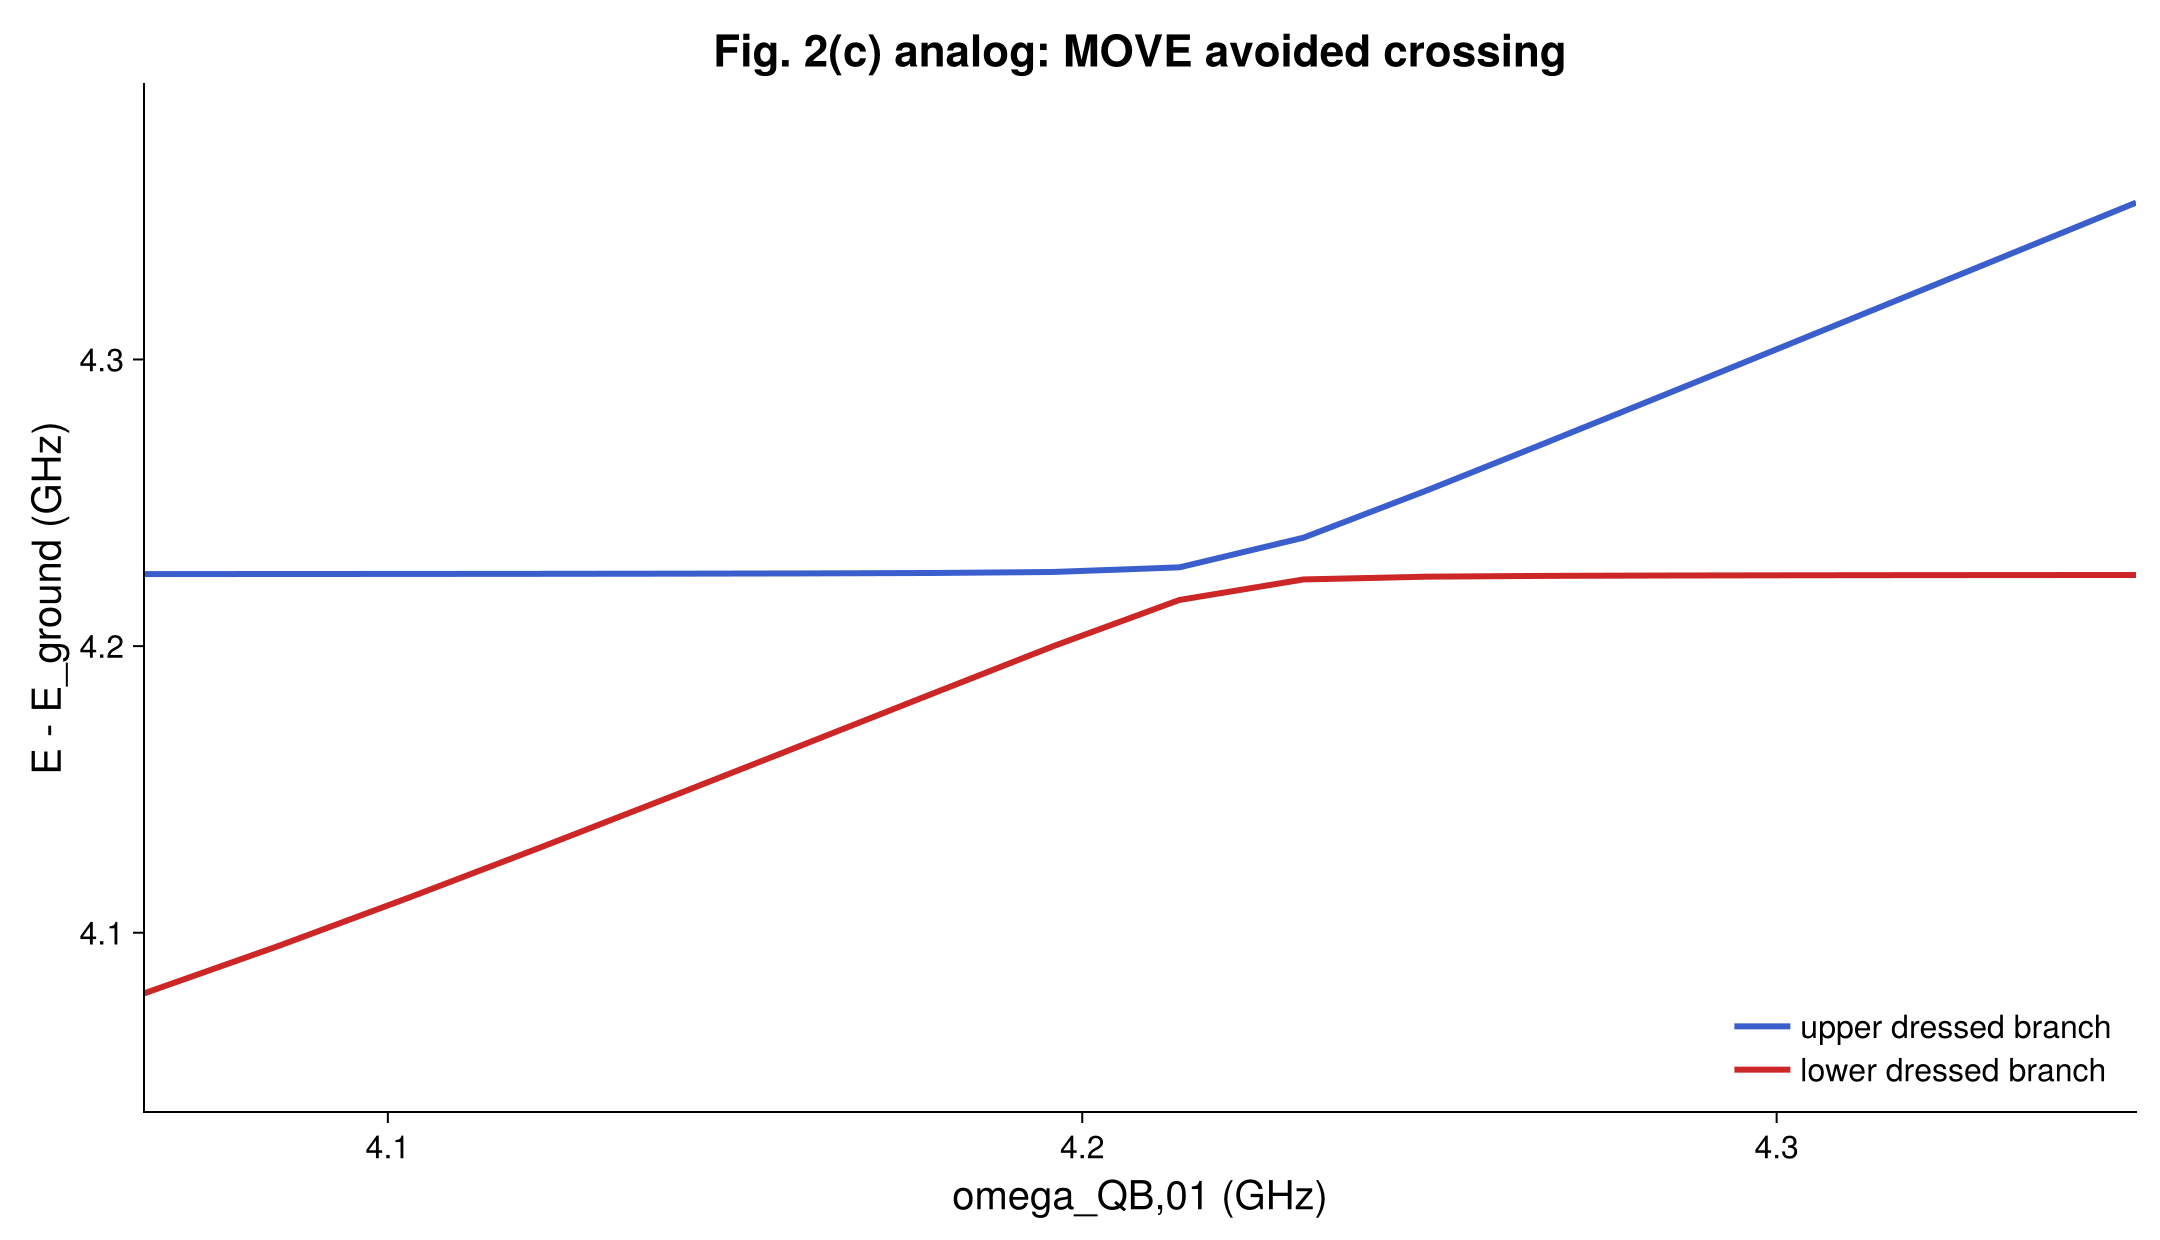

(saved = (svg = "/Users/yalgaeahn/Research/20_Projects/QuantumCircuit.jl/output/figures/renger2026/figure2c_move_avoided_crossing.svg", png = "/Users/yalgaeahn/Research/20_Projects/QuantumCircuit.jl/output/figures/renger2026/figure2c_move_avoided_crossing.png"), plotted_tc_flux = 0.34, highlighted_pair = (3, 4), move_reference = (q_flux = 0.21, q_ghz = 4.3517, tc_flux = 0.34, tc_ghz = 4.0177, pair_abs = (3, 4), gap_ghz = 0.1299, a_pair_support = 0.9916, b_pair_support = 0.9767, score = 2.1578), move_reference_third_mode = (rel_index = 1.0, abs_index = 2.0, support = 0.0316, comparable = 0.0), move_gap = (q_flux = 0.23, q_ghz = 4.214, tc_flux = 0.34, tc_ghz = 4.0177, pair_abs = (3, 4), gap_ghz = 0.0114, lower_a_overlap = 0.7635, lower_b_overlap = 0.233, upper_a_overlap = 0.2142, upper_b_overlap = 0.7444, a_pair_support = 0.9777, b_pair_support = 0.9774, lower_branch_support = 0.9965, upper_branch_support = 0.9586, support_score = 2.1277, third_mode_abs_index = 2.0, third_mode_support = 

In [5]:
move_plot_tc_flux = FIG2_MOVE_PLOT_TC_FLUX
move_q_fluxes = collect(range(0.21, 0.25; length = 17))
move_rows = adiabatic_fan_rows(
    move_system,
    snapshot,
    move_q_fluxes,
    move_plot_tc_flux;
    branch_pair_a = (1, 0, 0),
    branch_pair_b = (0, 0, 1),
    which = :move,
    branch = :move,
    charge_cutoff = FIG2_CHARGE_CUTOFF,
)
move_pair = choose_highlighted_pair(move_rows)

move_x = [row.q_ghz for row in move_rows]
move_lower, move_upper = highlighted_pair_curves(move_rows, move_pair)
move_pair_span = maximum(move_upper) - minimum(move_lower)
move_y_pad = max(0.02, 0.15 * move_pair_span)
move_ylims = (minimum(move_lower) - move_y_pad, maximum(move_upper) + move_y_pad)
move_fan_curves = adiabatic_fan_curves(move_rows; ylims = move_ylims)
move_background_y = fan_y_values(move_fan_curves)
move_y_values = isempty(move_background_y) ? vcat(move_lower, move_upper) : vcat(move_lower, move_upper, move_background_y)
move_xlims = (minimum(move_x), maximum(move_x))
move_ylims = (minimum(move_y_values) - move_y_pad, maximum(move_y_values) + move_y_pad)

move_fig = line_figure(
    vcat(
        move_fan_curves,
        [
            (x = move_x, y = move_upper, label = "upper dressed branch", color = FIG2_COLORS.dressed_a),
            (x = move_x, y = move_lower, label = "lower dressed branch", color = FIG2_COLORS.dressed_b),
        ],
    );
    title = "Fig. 2(c) analog: MOVE avoided crossing",
    xlabel = "omega_QB,01 (GHz)",
    ylabel = "E - E_ground (GHz)",
    size = NOTEBOOK_WIDE,
    legend_position = :rb,
    xlims = move_xlims,
    ylims = move_ylims,
)
move_saved = save_figure(move_fig, repo_root, "figure2c_move_avoided_crossing")
figure_exports[:figure2c] = move_saved

display(move_fig)

move_gap = adiabatic_gap_summary(move_rows, move_pair)
move_validation = adiabatic_validation_summary(move_rows, move_pair, move_gap)
move_reference_third_mode = third_mode_support_summary(move_rows[move_pair.row_index], move_pair)

(
    saved = move_saved,
    plotted_tc_flux = round4(move_plot_tc_flux),
    highlighted_pair = move_pair.pair_abs,
    move_reference = compact_namedtuple((
        q_flux = move_pair.q_flux,
        q_ghz = move_pair.q_ghz,
        tc_flux = move_pair.tc_flux,
        tc_ghz = move_pair.tc_ghz,
        pair_abs = move_pair.pair_abs,
        gap_ghz = move_pair.gap_ghz,
        a_pair_support = move_pair.a_pair_support,
        b_pair_support = move_pair.b_pair_support,
        score = move_pair.score,
    )),
    move_reference_third_mode = compact_namedtuple(move_reference_third_mode),
    move_gap = compact_namedtuple(move_gap),
    move_validation = move_validation,
)


## Step 4 - Fig. 2(d) analog: CZ resonance avoided crossing

The CZ-side avoided crossing is built on the `QB2-TC2-CR` branch. As in the paper, the horizontal axis is the qubit frequency during the gate, `omega_QB,01`, while the tracked dressed branches come from the `|eg1⟩` and `|fg0⟩` manifold.


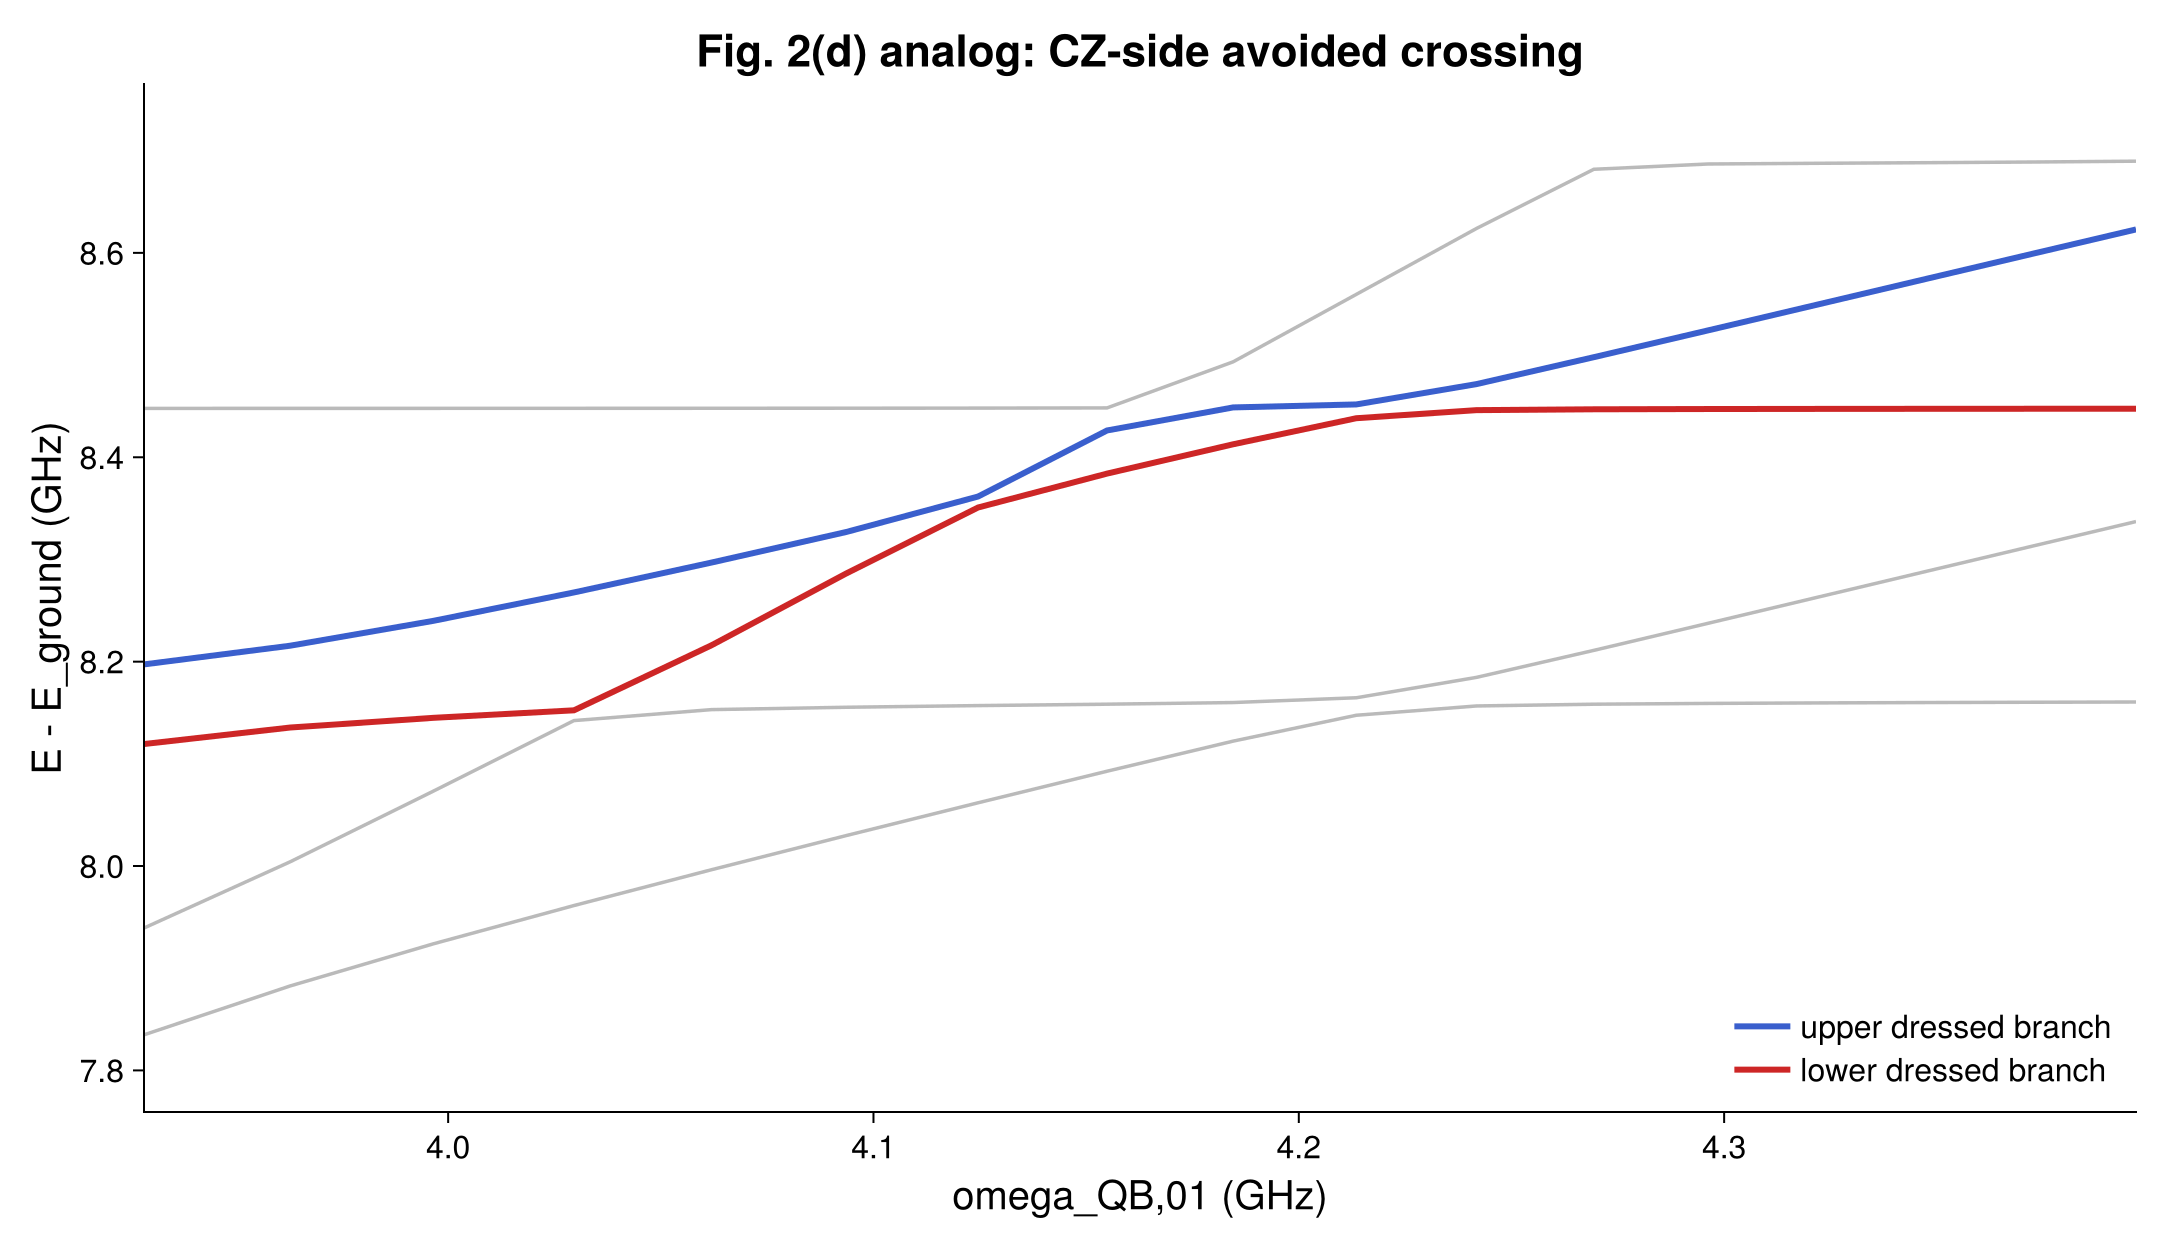

(saved = (svg = "/Users/yalgaeahn/Research/20_Projects/QuantumCircuit.jl/output/figures/renger2026/figure2d_cz_avoided_crossing.svg", png = "/Users/yalgaeahn/Research/20_Projects/QuantumCircuit.jl/output/figures/renger2026/figure2d_cz_avoided_crossing.png"), plotted_tc_flux = 0.34, highlighted_pair = (7, 8), cz_reference = (q_flux = 0.205, q_ghz = 4.1549, tc_flux = 0.34, tc_ghz = 3.9552, pair_abs = (7, 8), gap_ghz = 0.0422, a_pair_support = 0.9483, b_pair_support = 0.9743, score = 2.11), cz_reference_third_mode = (rel_index = 4.0, abs_index = 5.0, support = 0.041, comparable = 0.0), cz_gap = (q_flux = 0.21, q_ghz = 4.1246, tc_flux = 0.34, tc_ghz = 3.9552, pair_abs = (7, 8), gap_ghz = 0.0107, lower_a_overlap = 0.5392, lower_b_overlap = 0.4318, upper_a_overlap = 0.4048, upper_b_overlap = 0.5356, a_pair_support = 0.944, b_pair_support = 0.9674, lower_branch_support = 0.971, upper_branch_support = 0.9405, support_score = 2.059, third_mode_abs_index = 5.0, third_mode_support = 0.0467, third

In [6]:
cz_plot_tc_flux = FIG2_CZ_PLOT_TC_FLUX
cz_q_fluxes = collect(range(0.16, 0.24; length = 17))
cz_rows = adiabatic_fan_rows(
    cz_system,
    snapshot,
    cz_q_fluxes,
    cz_plot_tc_flux;
    branch_pair_a = (1, 0, 1),
    branch_pair_b = (2, 0, 0),
    which = :cz,
    branch = :cz,
    charge_cutoff = FIG2_CHARGE_CUTOFF,
)
cz_pair = choose_highlighted_pair(cz_rows)

cz_x = [row.q_ghz for row in cz_rows]
cz_lower, cz_upper = highlighted_pair_curves(cz_rows, cz_pair)
cz_pair_span = maximum(cz_upper) - minimum(cz_lower)
cz_y_pad = max(0.02, 0.15 * cz_pair_span)
cz_ylims = (minimum(cz_lower) - cz_y_pad, maximum(cz_upper) + cz_y_pad)
cz_fan_curves = adiabatic_fan_curves(cz_rows; ylims = cz_ylims)
cz_background_y = fan_y_values(cz_fan_curves)
cz_y_values = isempty(cz_background_y) ? vcat(cz_lower, cz_upper) : vcat(cz_lower, cz_upper, cz_background_y)
cz_xlims = (minimum(cz_x), maximum(cz_x))
cz_ylims = (minimum(cz_y_values) - cz_y_pad, maximum(cz_y_values) + cz_y_pad)

cz_fig = line_figure(
    vcat(
        cz_fan_curves,
        [
            (x = cz_x, y = cz_upper, label = "upper dressed branch", color = FIG2_COLORS.dressed_a),
            (x = cz_x, y = cz_lower, label = "lower dressed branch", color = FIG2_COLORS.dressed_b),
        ],
    );
    title = "Fig. 2(d) analog: CZ-side avoided crossing",
    xlabel = "omega_QB,01 (GHz)",
    ylabel = "E - E_ground (GHz)",
    size = NOTEBOOK_WIDE,
    legend_position = :rb,
    xlims = cz_xlims,
    ylims = cz_ylims,
)
cz_saved = save_figure(cz_fig, repo_root, "figure2d_cz_avoided_crossing")
figure_exports[:figure2d] = cz_saved

display(cz_fig)

cz_gap = adiabatic_gap_summary(cz_rows, cz_pair)
cz_validation = adiabatic_validation_summary(cz_rows, cz_pair, cz_gap)
cz_reference_third_mode = third_mode_support_summary(cz_rows[cz_pair.row_index], cz_pair)

(
    saved = cz_saved,
    plotted_tc_flux = round4(cz_plot_tc_flux),
    highlighted_pair = cz_pair.pair_abs,
    cz_reference = compact_namedtuple((
        q_flux = cz_pair.q_flux,
        q_ghz = cz_pair.q_ghz,
        tc_flux = cz_pair.tc_flux,
        tc_ghz = cz_pair.tc_ghz,
        pair_abs = cz_pair.pair_abs,
        gap_ghz = cz_pair.gap_ghz,
        a_pair_support = cz_pair.a_pair_support,
        b_pair_support = cz_pair.b_pair_support,
        score = cz_pair.score,
    )),
    cz_reference_third_mode = compact_namedtuple(cz_reference_third_mode),
    cz_gap = compact_namedtuple(cz_gap),
    cz_validation = cz_validation,
)


## Step 5 - Fig. 2(e) analog: fixed pulse-schedule MOVE resonator-proxy map

For the MOVE panel we initialize the parked branch-local diabatic state `|eg0⟩` on `QB1-TC1-CR`, ramp the qubit and coupler together to each scanned in-gate `(omega_QB, omega_TC)` point with `FluxControl`, hold for the active MOVE gate time, then ramp back to park.

The plotted color is the **final parked-basis resonator single-excitation proxy `P_CR,1` after the full pulse**. This is the closest branch-local notebook surrogate to the paper's MOVE population map without recreating the full Appendix D pulse stack.


In [ ]:
move_scan_axes = branch_flux_axes(:move; q_points = 21, tc_points = 21)
move_scan_q_fluxes = move_scan_axes.q_fluxes
move_scan_tc_fluxes = move_scan_axes.tc_fluxes
move_t_gate = gate_times.move

move_osc_scan = adaptive_oscillation_metric_scan(
    move_system,
    snapshot,
    move_scan_q_fluxes,
    move_scan_tc_fluxes,
    (1, 0, 0),
    FIG2_MOVE_OSC_TLIST;
    branch = :move,
    metric = :move,
    charge_cutoff = FIG2_CHARGE_CUTOFF,
    t_min_ns = FIG2_OSC_T_MIN_NS,
)
move_osc_x, move_osc_y, move_osc_matrix = ordered_heatmap_axes(
    move_osc_scan.x_values,
    move_osc_scan.y_values,
    move_osc_scan.matrix,
)
move_osc_fig = heatmap_figure(
    move_osc_x,
    move_osc_y,
    move_osc_matrix;
    title = "Fig. 2(e) diagnostic: MOVE oscillation-envelope proxy",
    xlabel = "omega_QB,01 (GHz)",
    ylabel = "omega_TC (GHz)",
    colorlabel = "min_t P_e (MOVE qubit)",
    colorrange = (0.0, 1.0),
    xlims = (minimum(move_osc_x), maximum(move_osc_x)),
    ylims = (minimum(move_osc_y), maximum(move_osc_y)),
)
move_osc_saved = save_figure(move_osc_fig, repo_root, "figure2e_move_population_map_oscillation_proxy")
figure_exports[:figure2e_oscillation_proxy] = move_osc_saved

move_scan = adaptive_pulse_population_scan(
    move_system,
    snapshot,
    move_scan_q_fluxes,
    move_scan_tc_fluxes,
    (1, 0, 0),
    move_t_gate;
    branch = :move,
    metric = :move_cr1,
    objective = :max,
    ramp_ns = FIG2_MOVE_RAMP_NS,
    charge_cutoff = FIG2_CHARGE_CUTOFF,
)

x_move = move_scan.x_values
y_move = move_scan.y_values
matrix_move = move_scan.matrix
move_qubit_final_pe_matrix = clamp.(1 .- move_scan.aux_matrix, 0.0, 1.0)
move_transfer_matrix = clamp.(move_scan.aux_matrix, 0.0, 1.0)
x_move_sorted, y_move_sorted, matrix_move_sorted = ordered_heatmap_axes(x_move, y_move, matrix_move)
_, _, move_qubit_final_pe_sorted = ordered_heatmap_axes(x_move, y_move, move_qubit_final_pe_matrix)
_, _, move_transfer_sorted = ordered_heatmap_axes(x_move, y_move, move_transfer_matrix)
best_move_point = move_scan.best_point
move_full_display = (
    xlims = (minimum(x_move_sorted), maximum(x_move_sorted)),
    ylims = (minimum(y_move_sorted), maximum(y_move_sorted)),
)
move_display = centered_span_window(
    best_move_point,
    x_move_sorted,
    y_move_sorted;
    delta_q_ghz = FIG2_ZOOM_Q_SPAN_GHZ,
    delta_tc_ghz = FIG2_MOVE_ZOOM_TC_SPAN_GHZ,
)

move_heatmap_fig = Figure(size = NOTEBOOK_WIDE)
ax_move = Axis(
    move_heatmap_fig[1, 1];
    title = "Fig. 2(e) analog: MOVE resonator single-excitation proxy after pulse",
    xlabel = "omega_QB,01 (GHz)",
    ylabel = "omega_TC (GHz)",
)
move_heatmap = heatmap!(
    ax_move,
    x_move_sorted,
    y_move_sorted,
    matrix_move_sorted';
    colormap = :Reds,
    colorrange = (0.0, 1.0),
)
xlims!(ax_move, move_display.xlims...)
ylims!(ax_move, move_display.ylims...)
scatter!(
    ax_move,
    [best_move_point.q_ghz],
    [best_move_point.tc_ghz];
    color = :white,
    strokecolor = :black,
    markersize = 12,
)
Colorbar(
    move_heatmap_fig[1, 2],
    move_heatmap;
    label = "final P_CR,1 proxy",
)
move_heatmap_saved = save_figure(move_heatmap_fig, repo_root, "figure2e_move_population_map")
figure_exports[:figure2e] = move_heatmap_saved

move_full_window_fig = Figure(size = NOTEBOOK_WIDE)
ax_move_full = Axis(
    move_full_window_fig[1, 1];
    title = "Fig. 2(e) diagnostic: MOVE resonator single-excitation proxy full scan",
    xlabel = "omega_QB,01 (GHz)",
    ylabel = "omega_TC (GHz)",
)
move_full_window_hm = heatmap!(
    ax_move_full,
    x_move_sorted,
    y_move_sorted,
    matrix_move_sorted';
    colormap = :Reds,
    colorrange = (0.0, 1.0),
)
xlims!(ax_move_full, move_full_display.xlims...)
ylims!(ax_move_full, move_full_display.ylims...)
scatter!(
    ax_move_full,
    [best_move_point.q_ghz],
    [best_move_point.tc_ghz];
    color = :white,
    strokecolor = :black,
    markersize = 12,
)
Colorbar(
    move_full_window_fig[1, 2],
    move_full_window_hm;
    label = "final P_CR,1 proxy",
)
move_full_window_saved = save_figure(move_full_window_fig, repo_root, "figure2e_move_population_map_full_window")
figure_exports[:figure2e_full_window] = move_full_window_saved

move_qubit_final_pe_fig = Figure(size = NOTEBOOK_WIDE)
ax_move_qubit_final_pe = Axis(
    move_qubit_final_pe_fig[1, 1];
    title = "Fig. 2(e) diagnostic: MOVE final qubit |e| probability after pulse",
    xlabel = "omega_QB,01 (GHz)",
    ylabel = "omega_TC (GHz)",
)
move_qubit_final_pe_hm = heatmap!(
    ax_move_qubit_final_pe,
    x_move_sorted,
    y_move_sorted,
    move_qubit_final_pe_sorted';
    colormap = :Reds,
    colorrange = (0.0, 1.0),
)
xlims!(ax_move_qubit_final_pe, move_full_display.xlims...)
ylims!(ax_move_qubit_final_pe, move_full_display.ylims...)
scatter!(
    ax_move_qubit_final_pe,
    [best_move_point.q_ghz],
    [best_move_point.tc_ghz];
    color = :white,
    strokecolor = :black,
    markersize = 12,
)
Colorbar(
    move_qubit_final_pe_fig[1, 2],
    move_qubit_final_pe_hm;
    label = "QB state probability",
    ticks = ([0.0, 1.0], ["|g⟩", "|e⟩"]),
)
move_qubit_final_pe_saved = save_figure(move_qubit_final_pe_fig, repo_root, "figure2e_move_population_map_qubit_final_pe")
figure_exports[:figure2e_qubit_final_pe] = move_qubit_final_pe_saved

move_transfer_fig = Figure(size = NOTEBOOK_WIDE)
ax_move_transfer = Axis(
    move_transfer_fig[1, 1];
    title = "Fig. 2(e) diagnostic: MOVE transfer score = 1 - final P_e",
    xlabel = "omega_QB,01 (GHz)",
    ylabel = "omega_TC (GHz)",
)
move_transfer_hm = heatmap!(
    ax_move_transfer,
    x_move_sorted,
    y_move_sorted,
    move_transfer_sorted';
    colormap = :viridis,
    colorrange = (0.0, 1.0),
)
xlims!(ax_move_transfer, move_full_display.xlims...)
ylims!(ax_move_transfer, move_full_display.ylims...)
scatter!(
    ax_move_transfer,
    [best_move_point.q_ghz],
    [best_move_point.tc_ghz];
    color = :white,
    strokecolor = :black,
    markersize = 12,
)
Colorbar(move_transfer_fig[1, 2], move_transfer_hm; label = "transfer score")
move_transfer_saved = save_figure(move_transfer_fig, repo_root, "figure2e_move_transfer_map")
figure_exports[:figure2e_transfer] = move_transfer_saved

move_zoom = dense_best_centered_pulse_population_scan(
    move_system,
    snapshot,
    move_scan,
    (1, 0, 0),
    move_t_gate;
    branch = :move,
    metric = :move_cr1,
    objective = :max,
    ramp_ns = FIG2_MOVE_RAMP_NS,
    charge_cutoff = FIG2_CHARGE_CUTOFF,
    q_span_ghz = FIG2_ZOOM_Q_SPAN_GHZ,
    tc_span_ghz = FIG2_MOVE_ZOOM_TC_SPAN_GHZ,
    q_points = FIG2_ZOOM_Q_POINTS,
    tc_points = FIG2_ZOOM_TC_POINTS,
)
move_zoom_fig = Figure(size = NOTEBOOK_WIDE)
ax_move_zoom = Axis(
    move_zoom_fig[1, 1];
    title = "Fig. 2(e) analog: dense best-centered MOVE resonator proxy zoom",
    xlabel = "omega_QB,01 (GHz)",
    ylabel = "omega_TC (GHz)",
)
move_zoom_hm = heatmap!(
    ax_move_zoom,
    move_zoom.x_sorted,
    move_zoom.y_sorted,
    move_zoom.matrix_sorted';
    colormap = :Reds,
    colorrange = (0.0, 1.0),
)
xlims!(ax_move_zoom, move_zoom.display.xlims...)
ylims!(ax_move_zoom, move_zoom.display.ylims...)
scatter!(
    ax_move_zoom,
    [move_zoom.best_point.q_ghz],
    [move_zoom.best_point.tc_ghz];
    color = :white,
    strokecolor = :black,
    markersize = 12,
)
Colorbar(
    move_zoom_fig[1, 2],
    move_zoom_hm;
    label = "final P_CR,1 proxy",
)
move_zoom_saved = save_figure(move_zoom_fig, repo_root, "figure2e_move_population_map_best_zoom")
figure_exports[:figure2e_best_zoom] = move_zoom_saved

move_best_trace = pulse_population_trace(
    move_system,
    snapshot,
    best_move_point.q_flux,
    best_move_point.tc_flux,
    (1, 0, 0),
    move_t_gate;
    branch = :move,
    ramp_ns = FIG2_MOVE_RAMP_NS,
    charge_cutoff = FIG2_CHARGE_CUTOFF,
)
move_trace_fig = Figure(size = NOTEBOOK_TALL)
ax_move_trace = Axis(
    move_trace_fig[1, 1];
    title = "MOVE best-point pulse trace",
    xlabel = "time (ns)",
    ylabel = "probability",
)
lines!(ax_move_trace, move_best_trace.times, move_best_trace.p_e; color = :firebrick3, linewidth = 3, label = "P_e")
lines!(ax_move_trace, move_best_trace.times, move_best_trace.p_g; color = :royalblue3, linewidth = 3, label = "P_g")
lines!(ax_move_trace, move_best_trace.times, move_best_trace.p_cr1; color = :darkgreen, linewidth = 3, label = "P_CR,1 proxy")
vlines!(ax_move_trace, [move_best_trace.final_time_ns]; color = :black, linestyle = :dot)
axislegend(ax_move_trace; position = :rb)
move_trace_saved = save_figure(move_trace_fig, repo_root, "figure2e_move_best_trace")
figure_exports[:figure2e_best_trace] = move_trace_saved

display(move_heatmap_fig)
display(move_full_window_fig)
display(move_qubit_final_pe_fig)
display(move_transfer_fig)
display(move_zoom_fig)
display(move_trace_fig)

(
    oscillation_proxy_saved = move_osc_saved,
    main_saved = move_heatmap_saved,
    full_window_saved = move_full_window_saved,
    qubit_final_pe_saved = move_qubit_final_pe_saved,
    transfer_saved = move_transfer_saved,
    best_zoom_saved = move_zoom_saved,
    best_trace_saved = move_trace_saved,
    coarse_best_point = compact_namedtuple(best_move_point),
    dense_best_point = compact_namedtuple(move_zoom.best_point),
    selected_best_time_ns = round4(best_move_point.best_time_ns),
    final_p_cr1_proxy = round4(best_move_point.value),
    transfer_score = round4(move_best_trace.transfer_score),
    final_p_e = round4(move_best_trace.final_p_e),
    leakage_proxy = round4(move_best_trace.final_leakage_proxy),
    main_display = compact_namedtuple(move_display),
    full_window_display = compact_namedtuple(move_full_display),
    requested_zoom = compact_namedtuple(move_zoom.requested_span_ghz),
    realized_zoom = compact_namedtuple(move_zoom.realized_span_ghz),
    dense_grid = move_zoom.grid_size,
)


## Step 6 - Fig. 2(f) analog: fixed pulse-schedule CZ state-probability map

For the CZ panel we initialize the parked branch-local diabatic state `|eg1⟩` on `QB2-TC2-CR`, ramp the qubit and coupler together to each scanned in-gate `(omega_QB, omega_TC)` point with `FluxControl`, hold for the active CZ gate time, then ramp back to park.

The plotted color is the **final parked-basis qubit `|f⟩` probability after the full pulse**. This is a branch-local fixed pulse-schedule surrogate for the paper's CZ calibration panel, not yet the full `MOVE -> CZ -> MOVE` readout stack.


In [ ]:
cz_scan_axes = branch_flux_axes(:cz; q_points = 21, tc_points = 21)
cz_scan_q_fluxes = cz_scan_axes.q_fluxes
cz_scan_tc_fluxes = cz_scan_axes.tc_fluxes
cz_t_gate = gate_times.cz

cz_osc_scan = adaptive_oscillation_metric_scan(
    cz_system,
    snapshot,
    cz_scan_q_fluxes,
    cz_scan_tc_fluxes,
    (1, 0, 1),
    FIG2_CZ_OSC_TLIST;
    branch = :cz,
    metric = :cz,
    charge_cutoff = FIG2_CHARGE_CUTOFF,
    t_min_ns = FIG2_OSC_T_MIN_NS,
    f_threshold = FIG2_CZ_RETURN_F_THRESHOLD,
)
cz_osc_x, cz_osc_y, cz_osc_matrix = ordered_heatmap_axes(
    cz_osc_scan.x_values,
    cz_osc_scan.y_values,
    cz_osc_scan.matrix,
)
cz_osc_fig = heatmap_figure(
    cz_osc_x,
    cz_osc_y,
    cz_osc_matrix;
    title = "Fig. 2(f) diagnostic: CZ oscillation-envelope proxy",
    xlabel = "omega_QB,01 (GHz)",
    ylabel = "omega_TC (GHz)",
    colorlabel = "1 - max return score",
    colorrange = (0.0, 1.0),
    xlims = (minimum(cz_osc_x), maximum(cz_osc_x)),
    ylims = (minimum(cz_osc_y), maximum(cz_osc_y)),
)
cz_osc_saved = save_figure(cz_osc_fig, repo_root, "figure2f_cz_population_map_oscillation_proxy")
figure_exports[:figure2f_oscillation_proxy] = cz_osc_saved

cz_scan = adaptive_pulse_population_scan(
    cz_system,
    snapshot,
    cz_scan_q_fluxes,
    cz_scan_tc_fluxes,
    (1, 0, 1),
    cz_t_gate;
    branch = :cz,
    metric = :cz,
    objective = :max,
    ramp_ns = FIG2_CZ_RAMP_NS,
    charge_cutoff = FIG2_CHARGE_CUTOFF,
)

x_cz = cz_scan.x_values
y_cz = cz_scan.y_values
matrix_cz = cz_scan.matrix
x_cz_sorted, y_cz_sorted, matrix_cz_sorted = ordered_heatmap_axes(x_cz, y_cz, matrix_cz)
best_cz_point = cz_scan.best_point
cz_display = (
    xlims = (minimum(x_cz_sorted), maximum(x_cz_sorted)),
    ylims = (minimum(y_cz_sorted), maximum(y_cz_sorted)),
)

cz_heatmap_fig = Figure(size = NOTEBOOK_WIDE)
ax_cz = Axis(
    cz_heatmap_fig[1, 1];
    title = "Fig. 2(f) analog: CZ final qubit-state probability after pulse",
    xlabel = "omega_QB,01 (GHz)",
    ylabel = "omega_TC (GHz)",
)
cz_heatmap = heatmap!(
    ax_cz,
    x_cz_sorted,
    y_cz_sorted,
    matrix_cz_sorted';
    colormap = :Blues,
    colorrange = (0.0, 1.0),
)
xlims!(ax_cz, cz_display.xlims...)
ylims!(ax_cz, cz_display.ylims...)
scatter!(
    ax_cz,
    [best_cz_point.q_ghz],
    [best_cz_point.tc_ghz];
    color = :white,
    strokecolor = :black,
    markersize = 12,
)
Colorbar(
    cz_heatmap_fig[1, 2],
    cz_heatmap;
    label = "QB state probability",
    ticks = ([0.0, 1.0], ["|e⟩", "|f⟩"]),
)
cz_heatmap_saved = save_figure(cz_heatmap_fig, repo_root, "figure2f_cz_population_map")
figure_exports[:figure2f] = cz_heatmap_saved

cz_zoom = dense_best_centered_pulse_population_scan(
    cz_system,
    snapshot,
    cz_scan,
    (1, 0, 1),
    cz_t_gate;
    branch = :cz,
    metric = :cz,
    objective = :max,
    ramp_ns = FIG2_CZ_RAMP_NS,
    charge_cutoff = FIG2_CHARGE_CUTOFF,
    q_span_ghz = FIG2_ZOOM_Q_SPAN_GHZ,
    tc_span_ghz = FIG2_CZ_ZOOM_TC_SPAN_GHZ,
    q_points = FIG2_ZOOM_Q_POINTS,
    tc_points = FIG2_ZOOM_TC_POINTS,
)
cz_zoom_fig = Figure(size = NOTEBOOK_WIDE)
ax_cz_zoom = Axis(
    cz_zoom_fig[1, 1];
    title = "Fig. 2(f) analog: dense best-centered CZ pulse zoom",
    xlabel = "omega_QB,01 (GHz)",
    ylabel = "omega_TC (GHz)",
)
cz_zoom_hm = heatmap!(
    ax_cz_zoom,
    cz_zoom.x_sorted,
    cz_zoom.y_sorted,
    cz_zoom.matrix_sorted';
    colormap = :Blues,
    colorrange = (0.0, 1.0),
)
xlims!(ax_cz_zoom, cz_zoom.display.xlims...)
ylims!(ax_cz_zoom, cz_zoom.display.ylims...)
scatter!(
    ax_cz_zoom,
    [cz_zoom.best_point.q_ghz],
    [cz_zoom.best_point.tc_ghz];
    color = :white,
    strokecolor = :black,
    markersize = 12,
)
Colorbar(
    cz_zoom_fig[1, 2],
    cz_zoom_hm;
    label = "QB state probability",
    ticks = ([0.0, 1.0], ["|e⟩", "|f⟩"]),
)
cz_zoom_saved = save_figure(cz_zoom_fig, repo_root, "figure2f_cz_population_map_best_zoom")
figure_exports[:figure2f_best_zoom] = cz_zoom_saved

cz_best_trace = pulse_population_trace(
    cz_system,
    snapshot,
    best_cz_point.q_flux,
    best_cz_point.tc_flux,
    (1, 0, 1),
    cz_t_gate;
    branch = :cz,
    ramp_ns = FIG2_CZ_RAMP_NS,
    charge_cutoff = FIG2_CHARGE_CUTOFF,
)
cz_trace_fig = Figure(size = NOTEBOOK_TALL)
ax_cz_trace = Axis(
    cz_trace_fig[1, 1];
    title = "CZ best-point pulse trace",
    xlabel = "time (ns)",
    ylabel = "probability",
)
lines!(ax_cz_trace, cz_best_trace.times, cz_best_trace.p_e; color = :royalblue3, linewidth = 3, label = "P_e")
lines!(ax_cz_trace, cz_best_trace.times, cz_best_trace.p_f; color = :goldenrod3, linewidth = 3, label = "P_f")
vlines!(ax_cz_trace, [cz_best_trace.final_time_ns]; color = :black, linestyle = :dot)
axislegend(ax_cz_trace; position = :rb)
cz_trace_saved = save_figure(cz_trace_fig, repo_root, "figure2f_cz_best_trace")
figure_exports[:figure2f_best_trace] = cz_trace_saved

display(cz_heatmap_fig)
display(cz_zoom_fig)
display(cz_trace_fig)

(
    oscillation_proxy_saved = cz_osc_saved,
    main_saved = cz_heatmap_saved,
    best_zoom_saved = cz_zoom_saved,
    best_trace_saved = cz_trace_saved,
    coarse_best_point = compact_namedtuple(best_cz_point),
    dense_best_point = compact_namedtuple(cz_zoom.best_point),
    selected_best_time_ns = round4(best_cz_point.best_time_ns),
    final_p_e = round4(best_cz_point.aux),
    requested_zoom = compact_namedtuple(cz_zoom.requested_span_ghz),
    realized_zoom = compact_namedtuple(cz_zoom.realized_span_ghz),
    dense_grid = cz_zoom.grid_size,
)


## Step 7 - Pulse-schedule sanity check and computational-phase interpretation

The scan panels above now use the same parked-to-gate `FluxControl` schedule for their main observable. Here we simply report the final parked-basis qubit probabilities at the selected MOVE and CZ best points, then compare that with a `QB-CR` computational-phase proxy on the CZ branch.

As before, a localized population lobe identifies the **resonance mechanism** and an experimentally useful operating-point signal, not by itself a finished calibrated logical gate.


In [ ]:
move_pulse_summary = final_pulse_state_probabilities(
    move_system,
    snapshot,
    best_move_point.q_flux,
    best_move_point.tc_flux,
    (1, 0, 0),
    move_t_gate;
    branch = :move,
    ramp_ns = FIG2_MOVE_RAMP_NS,
    charge_cutoff = FIG2_CHARGE_CUTOFF,
)

cz_pulse_summary = final_pulse_state_probabilities(
    cz_system,
    snapshot,
    best_cz_point.q_flux,
    best_cz_point.tc_flux,
    (1, 0, 1),
    cz_t_gate;
    branch = :cz,
    ramp_ns = FIG2_CZ_RAMP_NS,
    charge_cutoff = FIG2_CHARGE_CUTOFF,
)

cz_phase_proxy = pulse_computational_phase_summary(
    cz_system,
    snapshot,
    best_cz_point.q_flux,
    best_cz_point.tc_flux,
    cz_t_gate;
    branch = :cz,
    ramp_ns = FIG2_CZ_RAMP_NS,
    charge_cutoff = FIG2_CHARGE_CUTOFF,
)

(
    move_selected = compact_namedtuple(best_move_point),
    move_pulse = compact_namedtuple(move_pulse_summary),
    move_transfer_score = round4(move_pulse_summary.transfer_score),
    move_final_p_cr1_proxy = round4(move_pulse_summary.final_p_cr1),
    move_leakage_proxy = round4(move_pulse_summary.leakage_proxy),
    cz_selected = compact_namedtuple(best_cz_point),
    cz_pulse = compact_namedtuple(cz_pulse_summary),
    cz_computational_phase = compact_namedtuple(cz_phase_proxy),
)


## Step 8 - Optional truncation cross-check

This notebook defaults to `charge_cutoff = 3` for interactivity. The cell below can rerun the selected pulse-schedule MOVE and CZ best points at `charge_cutoff = 4` to check that the qualitative story survives a modest truncation increase.


In [ ]:
if RUN_TRUNCATION_CHECKS
    move_cutoff4 = final_pulse_state_probabilities(
        move_system,
        snapshot,
        best_move_point.q_flux,
        best_move_point.tc_flux,
        (1, 0, 0),
        move_t_gate;
        branch = :move,
        ramp_ns = FIG2_MOVE_RAMP_NS,
        charge_cutoff = 4,
    )
    cz_cutoff4 = final_pulse_state_probabilities(
        cz_system,
        snapshot,
        best_cz_point.q_flux,
        best_cz_point.tc_flux,
        (1, 0, 1),
        cz_t_gate;
        branch = :cz,
        ramp_ns = FIG2_CZ_RAMP_NS,
        charge_cutoff = 4,
    )

    (
        move_cutoff3_final_p_e = round4(best_move_point.value),
        move_cutoff4_final_p_e = round4(move_cutoff4.final_p_e),
        cz_cutoff3_final_p_f = round4(best_cz_point.value),
        cz_cutoff4_final_p_f = round4(cz_cutoff4.final_p_f),
    )
else
    "Set RUN_TRUNCATION_CHECKS = true to rerun the pulse-schedule best points at charge_cutoff = 4."
end


## Takeaways

- The notebook reproduces the **qualitative avoided-crossing physics** behind Fig. 2(c) and Fig. 2(d) with branch-specific exact-circuit local models.
- The MOVE and CZ map panels are now built from the paper-backed branch split `QB1-TC1-CR` and `QB2-TC2-CR`, respectively.
- The main Fig. 2(e)(f) analogs are fixed pulse-schedule **final qubit-state probability** maps, while the older oscillation-envelope maps remain only as diagnostics.
- The best CZ-side resonance point found here still does **not** by itself produce a large computational conditional phase, which is expected. A real logical gate still needs calibrated pulse timing, phase handling, and the higher-level `MOVE -> CZ -> MOVE` composition.


In [ ]:
final_summary = (
    move_branch = branch_spec(:move).label,
    cz_branch = branch_spec(:cz).label,
    move_gap = compact_namedtuple(move_gap),
    cz_gap = compact_namedtuple(cz_gap),
    best_move_point = compact_namedtuple(best_move_point),
    best_cz_point = compact_namedtuple(best_cz_point),
    move_pulse = compact_namedtuple(move_pulse_summary),
    cz_pulse = compact_namedtuple(cz_pulse_summary),
    cz_computational_phase = compact_namedtuple(cz_phase_proxy),
    exported_figures = figure_exports,
)

final_summary
